Name: Blake Murphy

# Facial Emotion Recognition with CNNs

This notebook builds and evaluates convolutional neural networks for facial emotion recognition using the FER-style `train/` and `test/` image folder structure.

The workflow:

1. build a non-neural majority-class baseline;
2. train small and improved CNN models using only the training split;
3. compare experiments using the validation split;
4. retrain the selected configuration on train + validation data;
5. evaluate the final model once on the held-out test set;
6. inspect errors using a confusion matrix, classification report, misclassified examples, and Grad-CAM.


## Setup

This section imports the libraries used throughout the notebook. TensorFlow and Keras are used for deep learning, NumPy and pandas are used for data handling and experiment tracking, matplotlib is used for visualisation, and scikit learn is used for class weighting and evaluation metrics.

A fixed random seed is used to improve reproducibility across runs. Dataset paths, image dimensions, batch size, and output directories are also defined here. The path assertions provide an early sanity check so that training does not begin with an incorrect folder structure.

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

SEED = 42
keras.utils.set_random_seed(SEED)

# Expected structure:
# archive/
#   train/
#     angry/, disgust/, fear/, happy/, neutral/, sad/, surprise/
#   test/
#     angry/, disgust/, fear/, happy/, neutral/, sad/, surprise/
DATASET_PATH = Path(os.getenv("FER_DATASET_PATH", "archive"))
train_dir = DATASET_PATH / "train"
test_dir = DATASET_PATH / "test"

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE
SHUFFLE_BUFFER = 4096

RUNS_DIR = Path("runs")
OUTPUT_DIR = Path("outputs")
RUNS_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

assert train_dir.exists(), f"Missing train dir: {train_dir.resolve()}"
assert test_dir.exists(), f"Missing test dir: {test_dir.resolve()}"

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Dataset path:", DATASET_PATH.resolve())


TensorFlow: 2.18.1
Keras: 3.11.2
Dataset path: C:\Users\palim\archive


## Data loading

The dataset (link in references) is loaded from directory structure using `image_dataset_from_directory`. The original training directory is split into training and validation subsets using a fixed random seed so that the split is consistent across runs. The test set is loaded separately and is not shuffled so that evaluation and later diagnostic steps remain stable.

Images are loaded in grayscale format at 48 by 48 pixels, which matches the original dataset format. Labels are stored as integer class indices so that the models can be trained using sparse categorical cross entropy.

In [2]:
train_dataset_raw = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,  # split training data into train/validation
    subset="training",
    seed=SEED,  # ensures same split each run
    image_size=IMG_SIZE,  # resize all images to 48x48
    batch_size=BATCH_SIZE,
    color_mode="grayscale",  # FER dataset is grayscale
    label_mode="int",  # integer labels for sparse_categorical_crossentropy
)

val_dataset_raw = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="int",
)

test_dataset_raw = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="int",
    shuffle=False,  # keep order fixed for evaluation and confusion matrix
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


### Evaluation discipline

The original training directory is split into training and validation subsets. The separate test directory is kept untouched during model development and is used only once after the final configuration has been selected.


## Label mapping

This section records the class names inferred from the directory structure and the total number of classes. This mapping is used throughout the notebook for reporting, plotting, confusion matrices, and interpretation of model predictions.

It is important that this mapping is checked early, because any mistake here would affect every later evaluation step.

In [3]:
CLASS_NAMES = train_dataset_raw.class_names  # list of emotion labels inferred from folder names
NUM_CLASSES = len(CLASS_NAMES)  # total number of classes

print("Class names:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


## Input pipeline configuration

The datasets are configured for efficient training and evaluation. The training data is shuffled so that each epoch sees the samples in a different order, which improves optimisation behaviour. Prefetching is used so that input preparation can overlap with model execution.

Validation and test sets are not shuffled during evaluation, since stable ordering is useful for consistent metrics and later error analysis.

In [4]:
def configure_ds(ds, training=False, cache=False):
    """Configure a tf.data pipeline.

    Caching can speed up repeated local experiments, but it is optional because
    large datasets may not fit comfortably in memory on every machine.
    """
    if cache:
        ds = ds.cache()
    if training:
        ds = ds.shuffle(SHUFFLE_BUFFER, seed=SEED, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

train_dataset = configure_ds(train_dataset_raw, training=True)
val_dataset = configure_ds(val_dataset_raw)
test_dataset = configure_ds(test_dataset_raw)


## Transfer learning preprocessing

A separate preprocessing pipeline is defined for transfer learning with MobileNetV2. The grayscale facial images are resized to a larger spatial resolution, converted from one channel to three channels, and then passed through the MobileNetV2 preprocessing function so that they match the format expected by the pretrained model.

This transfer learning pipeline is kept separate from the custom CNN pipeline so that both approaches can be compared cleanly.

In [5]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

TL_BATCH_SIZE = 16
IMG_SIZE_TL = (128, 128)

def prepare_for_transfer(image, label):
    image = tf.cast(image, tf.float32)  # ensure correct dtype
    image = tf.image.resize(image, IMG_SIZE_TL)  # resize to MobileNet input size
    image = tf.image.grayscale_to_rgb(image)  # convert 1 channel → 3 channels
    image = preprocess_input(image)  # MobileNetV2-specific normalization
    return image, label


train_dataset_tl = train_dataset_raw.unbatch().batch(TL_BATCH_SIZE).map(
    prepare_for_transfer, num_parallel_calls=AUTOTUNE
)
val_dataset_tl = val_dataset_raw.unbatch().batch(TL_BATCH_SIZE).map(
    prepare_for_transfer, num_parallel_calls=AUTOTUNE
)
test_dataset_tl = test_dataset_raw.unbatch().batch(TL_BATCH_SIZE).map(
    prepare_for_transfer, num_parallel_calls=AUTOTUNE
)

train_dataset_tl = configure_ds(train_dataset_tl, training=True)
val_dataset_tl = configure_ds(val_dataset_tl, training=False)
test_dataset_tl = configure_ds(test_dataset_tl, training=False)

In [6]:
def build_transfer_model(
    dense_units=128,
    dropout_rate=0.3,
    lr_head=1e-4,
):
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE_TL[0], IMG_SIZE_TL[1], 3),  # expects RGB input
        include_top=False,  # remove original ImageNet classifier
        weights="imagenet",  # use pretrained ImageNet weights
        alpha=0.35,  # lighter MobileNet to reduce memory usage
    )
    base_model.trainable = False  # freeze backbone for head-only training

    inputs = keras.Input(shape=(IMG_SIZE_TL[0], IMG_SIZE_TL[1], 3))
    x = base_model(inputs, training=False)  # run frozen backbone in inference mode
    x = layers.GlobalAveragePooling2D()(x)  # reduce spatial feature maps to a vector
    x = layers.BatchNormalization()(x)  # stabilise the classifier head
    x = layers.Dense(dense_units, activation="relu")(x)  # small dense head for adaptation
    x = layers.Dropout(dropout_rate)(x)  # regularisation
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)  # final emotion probabilities

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_head),  # smaller LR for transfer learning
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model

## Dataset inspection

Before training, the notebook checks image and label shapes, data types, and pixel ranges. This step confirms that the dataset has been loaded correctly and that the preprocessing assumptions are valid.

A small sample of images is also plotted to verify that the labels correspond to the visible facial expressions and that there are no obvious loading or preprocessing issues.

In [7]:
for images, labels in train_dataset_raw.take(1):
    print("Image batch shape:", images.shape)  # expect (batch, 48, 48, 1)
    print("Label batch shape:", labels.shape)  # expect (batch,)
    print("Image dtype:", images.dtype)  # usually uint8 before normalization
    print("Label dtype:", labels.dtype)

for x_batch, _ in train_dataset_raw.take(1):
    x = tf.cast(x_batch, tf.float32)  # cast to float for inspection
    print("Raw pixel range:", float(tf.reduce_min(x)), "to", float(tf.reduce_max(x)))  # should be ~0–255

Image batch shape: (64, 48, 48, 1)
Label batch shape: (64,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Raw pixel range: 0.0 to 255.0


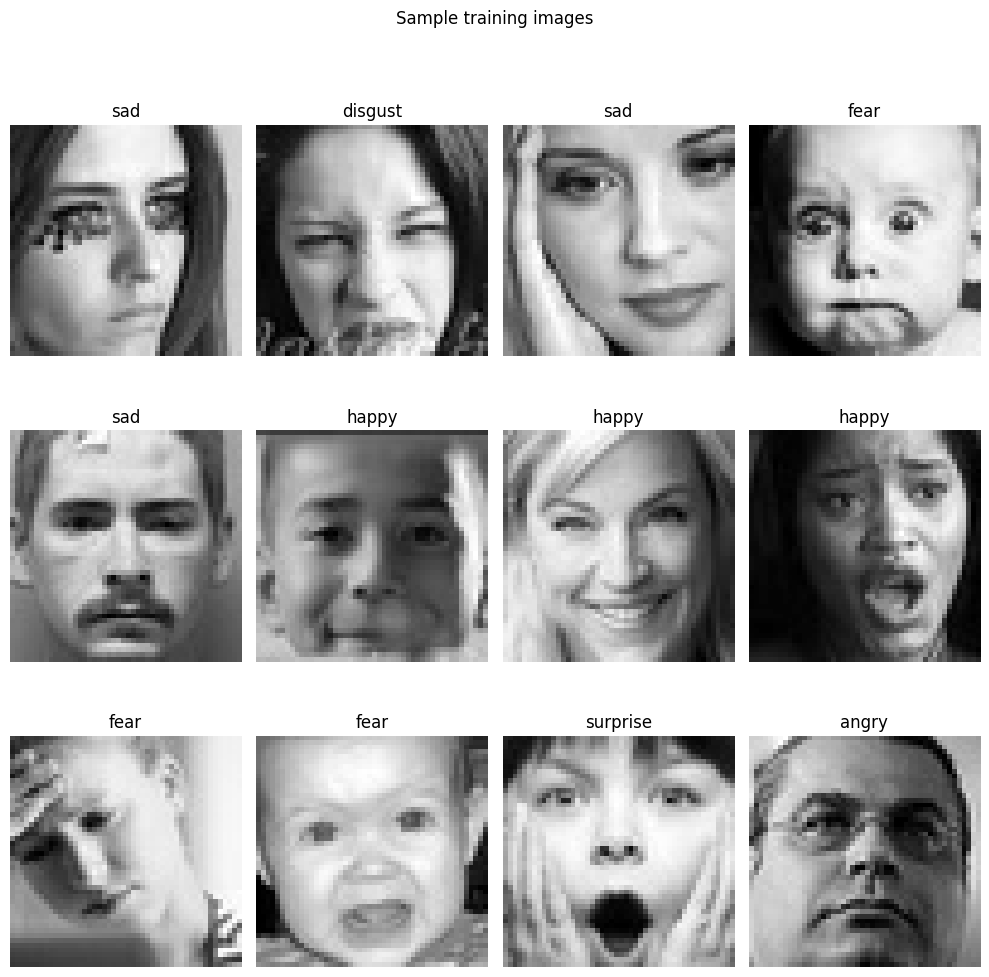

In [8]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset_raw.take(1):
    num_images = min(12, images.shape[0])  # handle smaller last batch safely
    for i in range(num_images):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")  # display grayscale image
        plt.title(CLASS_NAMES[int(labels[i])])  # show class label
        plt.axis("off")

plt.suptitle("Sample training images", y=1.02)
plt.tight_layout()
plt.show()

## Class distribution analysis

The number of samples in each class is computed and visualised in order to assess class imbalance. This matters because emotion datasets are rarely perfectly balanced, and underrepresented classes are often harder for the model to learn.

This analysis motivates the later class weight experiment and helps explain why some classes may remain more difficult than others during evaluation.

In [9]:
class_counts = {}

for class_name in CLASS_NAMES:
    class_path = train_dir / class_name  # Path object for cleaner handling
    class_counts[class_name] = len([
        f for f in class_path.iterdir()
        if f.is_file()  # count only files (images)
    ])

class_counts_df = pd.DataFrame({
    "class_name": list(class_counts.keys()),
    "count": list(class_counts.values())
})

class_counts_df.sort_values("count", ascending=False).reset_index(drop=True)

,class_name,count
0,happy,7215
1,neutral,4965
2,sad,4830
3,fear,4097
4,angry,3995
5,surprise,3171
6,disgust,436


In [10]:
print("Total training images:", class_counts_df["count"].sum())  # total number of training samples

print(
    "Largest class:",
    class_counts_df.loc[class_counts_df["count"].idxmax(), "class_name"],  # most frequent class
)

print(
    "Smallest class:",
    class_counts_df.loc[class_counts_df["count"].idxmin(), "class_name"],  # least frequent class
)

Total training images: 28709
Largest class: happy
Smallest class: disgust


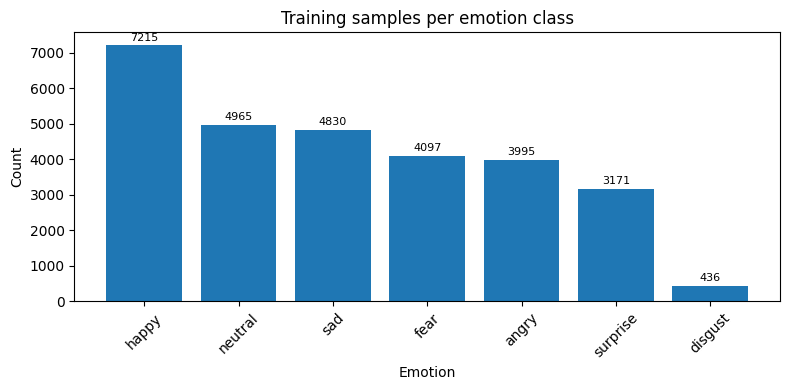

In [11]:
plt.figure(figsize=(8, 4))

df_sorted = class_counts_df.sort_values("count", ascending=False)  # sort for clearer visual comparison
bars = plt.bar(df_sorted["class_name"], df_sorted["count"])

plt.title("Training samples per emotion class")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(df_sorted["count"]) * 0.01,  # dynamic offset for readability
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

## Class weights

Class weights are computed from the training labels so that rarer classes can be given higher importance during training. The raw values are then clipped to reduce the risk of extremely large weights destabilising optimisation.

In this notebook, class weighting is treated as a separate controlled experiment rather than being enabled by default. This is useful because class weighting may improve minority class recall while slightly reducing overall accuracy.

In [12]:
all_train_labels = np.concatenate([
    labels.numpy() for _, labels in train_dataset_raw
])  # collect all labels from training dataset

class_weights_array = compute_class_weight(
    class_weight="balanced",  # inversely proportional to class frequency
    classes=np.arange(NUM_CLASSES),
    y=all_train_labels
)

class_weight_dict = {
    int(i): float(class_weights_array[i]) for i in range(NUM_CLASSES)
}  # convert to standard Python types for Keras

print("Class weights:", class_weight_dict)

Class weights: {0: 1.0196217703986505, 1: 9.03896103896104, 2: 0.998825831702544, 3: 0.5644491410877098, 4: 0.8275265717888669, 5: 0.8558014755197854, 6: 1.3177280550774526}


In [13]:
MAX_CLASS_WEIGHT = 5.0  # cap extreme weights to avoid instability

class_weight_dict_clipped = {
    int(k): float(min(v, MAX_CLASS_WEIGHT))  # ensure compatibility with Keras
    for k, v in class_weight_dict.items()
}

print("Clipped class weights:", class_weight_dict_clipped)

Clipped class weights: {0: 1.0196217703986505, 1: 5.0, 2: 0.998825831702544, 3: 0.5644491410877098, 4: 0.8275265717888669, 5: 0.8558014755197854, 6: 1.3177280550774526}


## Preprocessing layers for scratch CNNs

For the custom convolutional models, images are first rescaled from the original pixel range into the interval between zero and one. A learned `Normalization` layer is then adapted on the training data so that inputs are standardised using dataset statistics.

Mild data augmentation is also defined here. The transformations are intentionally conservative, because low resolution facial images are sensitive to excessive geometric distortion. The chosen augmentation introduces small but realistic variations while preserving the core facial structure.

In [14]:
rescale = layers.Rescaling(1.0 / 255.0, name="rescale")  # scale pixel values to [0,1]

pixel_normalizer = layers.Normalization(axis=-1, name="pixel_normalizer")  # learn dataset mean/std
pixel_normalizer.adapt(
    train_dataset_raw.map(
        lambda x, y: rescale(tf.cast(x, tf.float32)),  # rescale before adapting
        num_parallel_calls=AUTOTUNE
    )
)

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),  # horizontal flip for facial symmetry
        layers.RandomRotation(0.02, seed=SEED),  # small rotations
        layers.RandomZoom(0.05, seed=SEED),  # slight zoom variations
        layers.RandomTranslation(0.02, 0.02, seed=SEED),  # small shifts
        layers.RandomContrast(0.10, seed=SEED),  # lighting variation
    ],
    name="data_augmentation",
)

In [15]:
print("Class names:", CLASS_NAMES)  # list of emotion labels
print("Number of classes:", NUM_CLASSES)  # total number of categories
print("Class weights (raw):", class_weight_dict)  # computed inverse-frequency weights
print("Class weights (clipped):", class_weight_dict_clipped)  # capped weights for stability

Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Class weights (raw): {0: 1.0196217703986505, 1: 9.03896103896104, 2: 0.998825831702544, 3: 0.5644491410877098, 4: 0.8275265717888669, 5: 0.8558014755197854, 6: 1.3177280550774526}
Class weights (clipped): {0: 1.0196217703986505, 1: 5.0, 2: 0.998825831702544, 3: 0.5644491410877098, 4: 0.8275265717888669, 5: 0.8558014755197854, 6: 1.3177280550774526}


## Baselines

Before training neural networks, a simple common sense baseline is computed by always predicting the most frequent class in the training data. This provides a lower bound for performance and helps determine whether learned models are actually extracting meaningful patterns rather than exploiting class imbalance.

Following this, a baseline convolutional neural network is implemented to establish a stronger reference point. This model contains three convolutional blocks with batch normalisation and pooling, followed by global average pooling and a dense classifier with dropout.

The purpose of these baselines is to provide a clear progression. The common sense baseline represents the minimum expected performance, while the CNN baseline demonstrates what can be achieved with a simple learned model. All improved models are evaluated relative to these baselines.

In [16]:
def labels_from_dataset(ds):
    """Collect integer labels from a batched TensorFlow dataset."""
    return np.concatenate([labels.numpy() for _, labels in ds])

train_labels = labels_from_dataset(train_dataset_raw)
val_labels = labels_from_dataset(val_dataset_raw)
test_labels = labels_from_dataset(test_dataset_raw)

majority_class = np.bincount(train_labels).argmax()
majority_label = CLASS_NAMES[majority_class]

majority_val_predictions = np.full_like(val_labels, majority_class)
majority_val_accuracy = accuracy_score(val_labels, majority_val_predictions)

print(f"Majority class: {majority_label}")
print(f"Majority-class validation accuracy: {majority_val_accuracy:.4f}")


Majority class: happy
Majority-class validation accuracy: 0.2442


In [17]:
def build_baseline_model(lr=1e-3, dropout_rate=0.4):
    inputs = keras.Input(shape=(48, 48, 1), name="image")
    
    x = rescale(inputs)  # scale to [0,1]
    x = pixel_normalizer(x)  # normalize using dataset statistics

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)  # reduce spatial dimensions
    x = layers.Dense(128, activation="relu")(x)  # fully connected layer
    x = layers.Dropout(dropout_rate)(x)  # regularization to reduce overfitting
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)  # class probabilities

    model = keras.Model(inputs, outputs, name="baseline_cnn")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),  # standard optimizer
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## Improved CNN architecture

The improved model increases representational capacity by using a deeper convolutional structure, additional regularisation, and weight decay. Spatial dropout is included to regularise convolutional feature maps, and global average pooling is retained to keep the number of parameters manageable.

The main expectation is that this architecture will learn richer facial features than the baseline and therefore improve validation and test performance. The later results confirm that this expectation is correct.

In [18]:
def conv_bn_relu(x, filters, weight_decay=1e-4):
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_regularizer=keras.regularizers.l2(weight_decay),  # L2 regularization on conv weights
    )(x)
    x = layers.BatchNormalization()(x)  # stabilize activations during training
    return layers.Activation("relu")(x)  # non-linearity after normalization


def build_improved_model(
    use_augmentation=False,
    lr=3e-4,
    dropout_head=0.4,
    weight_decay=1e-4,
    use_adamw=True,
):
    inputs = keras.Input(shape=(48, 48, 1), name="image")
    x = inputs

    if use_augmentation:
        x = data_augmentation(x)  # apply augmentation only during training experiments

    x = rescale(x)  # scale pixels to [0,1]
    x = pixel_normalizer(x)  # normalize using training-set statistics

    x = conv_bn_relu(x, 32, weight_decay)
    x = conv_bn_relu(x, 32, weight_decay)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.10)(x)  # drop entire feature maps for CNN regularization

    x = conv_bn_relu(x, 64, weight_decay)
    x = conv_bn_relu(x, 64, weight_decay)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.15)(x)

    x = conv_bn_relu(x, 128, weight_decay)
    x = conv_bn_relu(x, 128, weight_decay)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.20)(x)

    x = conv_bn_relu(x, 256, weight_decay)
    x = conv_bn_relu(x, 256, weight_decay)

    x = layers.GlobalAveragePooling2D()(x)  # compact representation, fewer params than Flatten
    x = layers.Dropout(dropout_head)(x)  # regularize classifier head
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)  # final class probabilities

    model = keras.Model(inputs, outputs, name="cnn_bn_gap_deeper")

    if use_adamw:
        opt = keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)  # decoupled weight decay
    else:
        opt = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## Training curves

The helper function in the next cell plots training and validation accuracy and loss for each run. These plots are useful because they show the optimisation process directly and make it possible to identify underfitting, overfitting, and convergence behaviour.

Validation loss is used to identify the best epoch within a run, because it is a smoother and more sensitive indicator of generalisation. Validation accuracy is used to compare models across experiments, because it is easier to interpret as an overall performance measure.

In [19]:
def plot_history(history, title="Training curves"):
    hist = pd.DataFrame(history.history)  # convert history to DataFrame for easier plotting

    plt.figure(figsize=(10, 4))
    plt.plot(hist["accuracy"], label="train_acc")
    plt.plot(hist["val_accuracy"], label="val_acc")
    plt.title(title + " (Accuracy)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(title + " (Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    best_epoch = int(np.argmin(hist["val_loss"]) + 1)  # epoch with lowest validation loss
    print("Best epoch by val_loss:", best_epoch)

    return best_epoch

## Callbacks

The callback configuration makes the training workflow explicit and reproducible. Early stopping monitors validation loss and restores the best weights when improvement stops. Reduce learning rate on plateau lowers the learning rate automatically when progress stalls. Model checkpointing saves the best weights for each run, and CSV logging plus TensorBoard make it easier to inspect training later.

These callbacks are important for the report because they provide direct evidence that overfitting control and best epoch selection were built into the training procedure.

In [20]:
def make_callbacks(run_name, monitor="val_accuracy"):
    run_dir = RUNS_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    return [
        keras.callbacks.EarlyStopping(
            monitor=monitor,
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(run_dir / "best.weights.h5"),
            monitor=monitor,
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(str(run_dir / "history.csv")),
        keras.callbacks.TerminateOnNaN(),
    ]


## Controlled experiments

The following experiment loop compares the baseline model with several improved CNN variants. The experiments are designed so that changes are interpretable. The baseline provides a reference, and the improved architecture is then tested with and without augmentation, with different learning rates, and with class weighting.

The purpose is not simply to try many unrelated configurations, but to investigate whether specific controlled changes lead to better validation performance.

In [21]:
def run_experiment(
    name,
    build_fn,
    build_kwargs,
    train_ds,
    val_ds,
    epochs=50,
    class_weight=None,
):
    """Train one model configuration and return validation-only metrics.

    The held-out test set is intentionally not used here. Experiments are
    compared using validation metrics only; test evaluation happens once at
    the end after the final configuration has been selected.
    """
    tf.keras.backend.clear_session()
    print(f"\n=== Running: {name} ===")

    model = build_fn(**build_kwargs)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=make_callbacks(name),
        class_weight=class_weight,
        verbose=1,
    )

    best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)

    result = {
        "name": name,
        "val_loss": float(val_loss),
        "val_accuracy": float(val_acc),
        "best_epoch": best_epoch,
        "epochs_ran": len(history.history["loss"]),
        "class_weight": class_weight is not None,
        **build_kwargs,
    }

    print(f"→ {name} | val_acc={val_acc:.4f} | best_epoch={best_epoch}")
    return model, history, result


## Results comparison

The results table is the key summary of the experimental stage. It shows that the improved CNN models clearly outperform the baseline in this run. The best completed experiment is `improved_lr_1e-3`, which reaches validation accuracy 0.6408. The baseline reaches validation accuracy 0.55461. This means that the best improved model exceeds the baseline on validation accuracy.

This result supports the conclusion that the deeper architecture, together with augmentation and a suitable learning rate, provides an improvement over the simpler baseline.

In [22]:
all_models = {}
all_histories = {}
all_results = []

experiments = [
    dict(
        name="baseline_cnn",
        build_fn=build_baseline_model,
        build_kwargs=dict(lr=1e-3, dropout_rate=0.4),
        train_ds=train_dataset,
        val_ds=val_dataset,
        epochs=50,
        class_weight=None,
    ),
    dict(
        name="improved_deeper_adamw",
        build_fn=build_improved_model,
        build_kwargs=dict(
            use_augmentation=False,
            lr=3e-4,
            dropout_head=0.4,
            weight_decay=1e-4,
            use_adamw=True,
        ),
        train_ds=train_dataset,
        val_ds=val_dataset,
        epochs=80,
        class_weight=None,
    ),
    dict(
        name="improved_deeper_adamw_aug",
        build_fn=build_improved_model,
        build_kwargs=dict(
            use_augmentation=True,
            lr=3e-4,
            dropout_head=0.4,
            weight_decay=1e-4,
            use_adamw=True,
        ),
        train_ds=train_dataset,
        val_ds=val_dataset,
        epochs=80,
        class_weight=None,
    ),
    dict(
        name="improved_lr_1e-3",
        build_fn=build_improved_model,
        build_kwargs=dict(
            use_augmentation=True,
            lr=1e-3,
            dropout_head=0.4,
            weight_decay=1e-4,
            use_adamw=True,
        ),
        train_ds=train_dataset,
        val_ds=val_dataset,
        epochs=80,
        class_weight=None,
    ),
    dict(
        name="improved_lr_1e-4",
        build_fn=build_improved_model,
        build_kwargs=dict(
            use_augmentation=True,
            lr=1e-4,
            dropout_head=0.4,
            weight_decay=1e-4,
            use_adamw=True,
        ),
        train_ds=train_dataset,
        val_ds=val_dataset,
        epochs=80,
        class_weight=None,
    ),
    dict(
        name="improved_lr_1e-3_class_weights",
        build_fn=build_improved_model,
        build_kwargs=dict(
            use_augmentation=True,
            lr=1e-3,
            dropout_head=0.4,
            weight_decay=1e-4,
            use_adamw=True,
        ),
        train_ds=train_dataset,
        val_ds=val_dataset,
        epochs=80,
        class_weight=class_weight_dict_clipped,
    ),
]

for exp in experiments:
    model, history, result = run_experiment(
        name=exp["name"],
        build_fn=exp["build_fn"],
        build_kwargs=exp["build_kwargs"],
        train_ds=exp["train_ds"],
        val_ds=exp["val_ds"],
        epochs=exp["epochs"],
        class_weight=exp["class_weight"],
    )
    all_models[result["name"]] = model
    all_histories[result["name"]] = history
    all_results.append(result)

results_df = (
    pd.DataFrame(all_results)
    .sort_values("val_accuracy", ascending=False)
    .reset_index(drop=True)
)

print("Best validation model:", results_df.iloc[0]["name"])
results_df




=== Running: baseline_cnn ===
Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.28009, saving model to runs\baseline_cnn\best.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 97s 220ms/step - accuracy: 0.2734 - loss: 1.7774 - val_accuracy: 0.2801 - val_loss: 1.7474 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_accuracy improved from 0.28009 to 0.31928, saving model to runs\baseline_cnn\best.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 97s 234ms/step - accuracy: 0.3435 - loss: 1.6570 - val_accuracy: 0.3193 - val_loss: 1.8039 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_accuracy improved from 0.31928 to 0.39575, saving model to runs\baseline_cnn\best.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 98s 235ms/step - accuracy: 0.3919 - loss: 1.5626 - val_accuracy: 0.3957 - val_loss: 1.5364 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_accuracy did not improve from 0.39575
359/359 ━━━━━━━━━━━━━━━━━━━━ 94s 224ms/step - accuracy: 0.4194 - loss: 1.5011 - val_accuracy: 0.2345 - val_loss: 1.8919 - 

,name,val_loss,val_accuracy,best_epoch,epochs_ran,class_weight,lr,dropout_rate,use_augmentation,dropout_head,weight_decay,use_adamw
0,improved_lr_1e-3,1.096856,0.640829,40,48,False,0.0010,NaN,True,0.4,0.0001,True
1,improved_deeper_adamw_aug,1.064922,0.638216,55,63,False,0.0003,NaN,True,0.4,0.0001,True
2,improved_lr_1e-3_class_weights,1.109018,0.626546,38,46,True,0.0010,NaN,True,0.4,0.0001,True
3,improved_deeper_adamw,1.297342,0.624107,36,44,False,0.0003,NaN,False,0.4,0.0001,True
4,improved_lr_1e-4,1.113927,0.611218,37,45,False,0.0001,NaN,True,0.4,0.0001,True
5,baseline_cnn,1.212202,0.554607,32,40,False,0.0010,0.4,NaN,NaN,NaN,NaN


## Best model selection

The best model is selected using validation accuracy from the results table. In this notebook, the best model is `improved_lr_1e-3`. Its best epoch is 40 when selected by minimum validation loss, and the training process ended after 48 epochs due to early stopping.

In [23]:
best_row = results_df.iloc[0].to_dict()
best_name = best_row["name"]
best_model = all_models[best_name]
best_history = all_histories[best_name]
best_epoch = int(best_row["best_epoch"])

print("Selected configuration:", best_name)
print(f"Validation accuracy: {best_row['val_accuracy']:.4f}")
print("Selected epoch:", best_epoch)


Selected configuration: improved_lr_1e-3
Validation accuracy: 0.6408
Selected epoch: 40


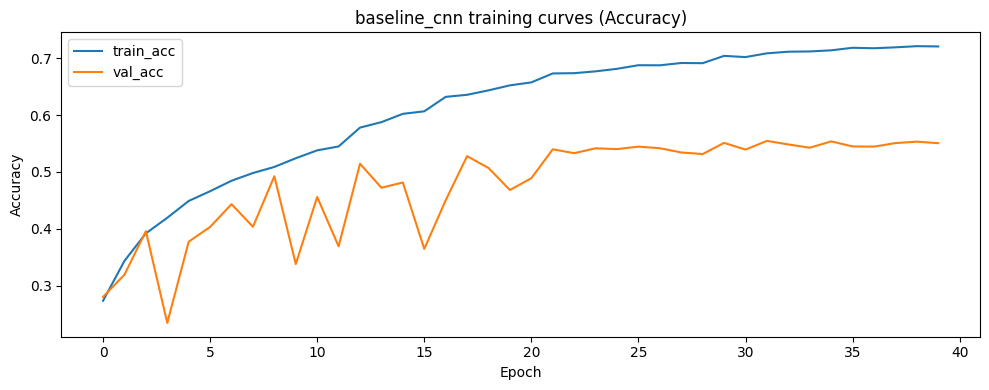

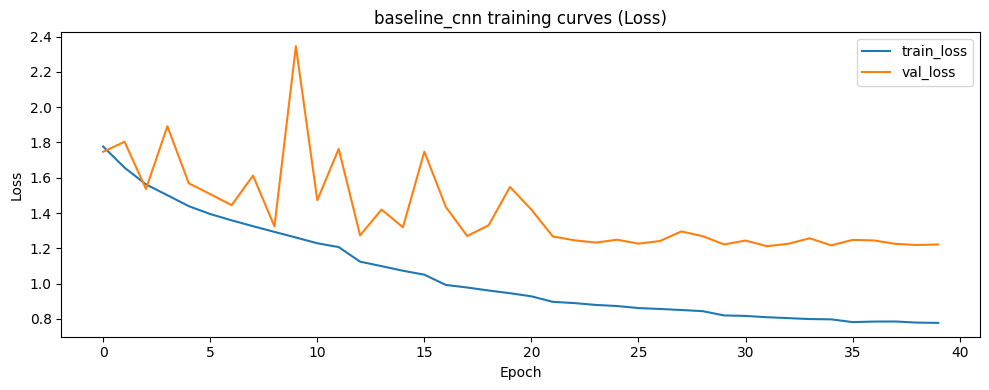

Best epoch by val_loss: 32


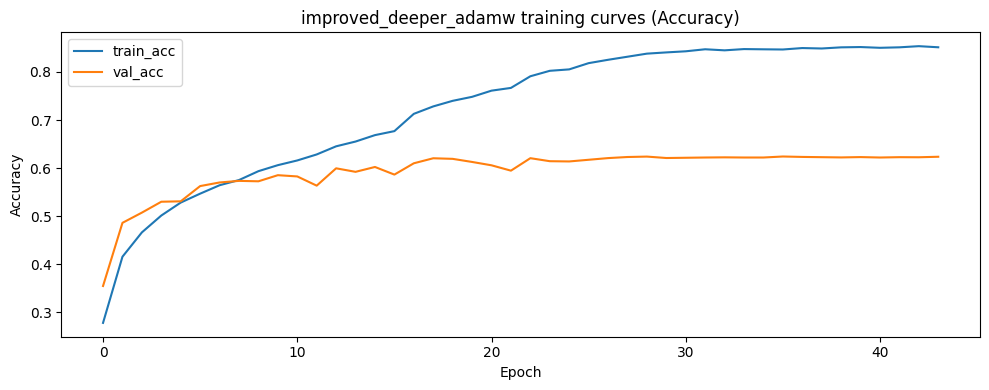

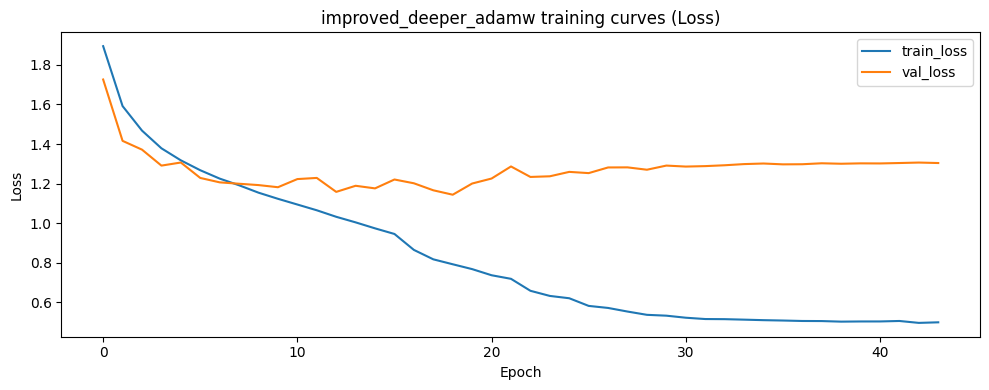

Best epoch by val_loss: 19


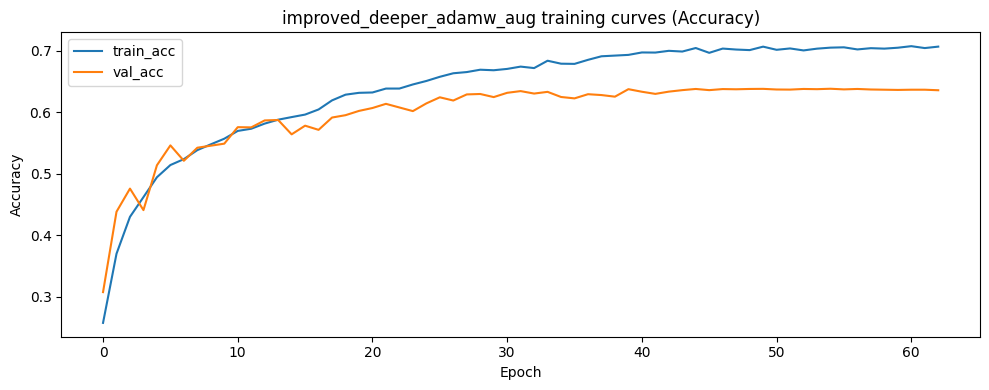

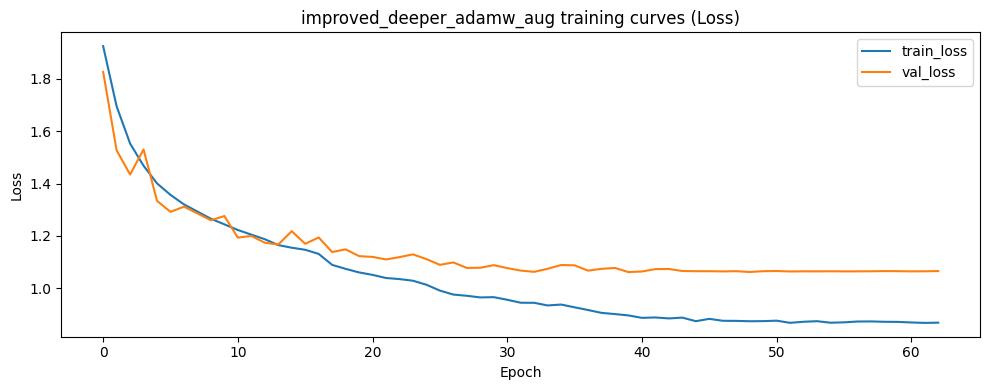

Best epoch by val_loss: 40


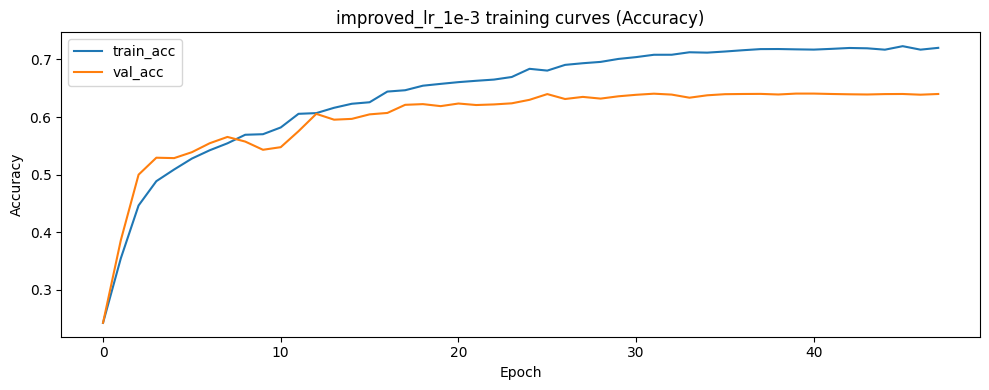

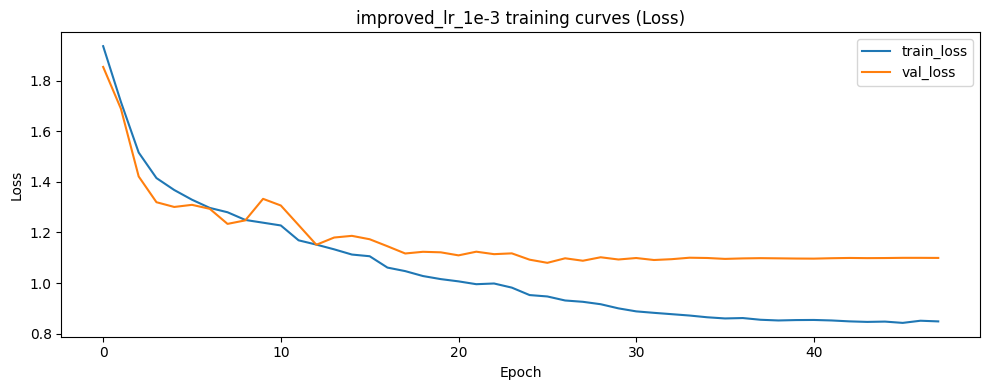

Best epoch by val_loss: 26


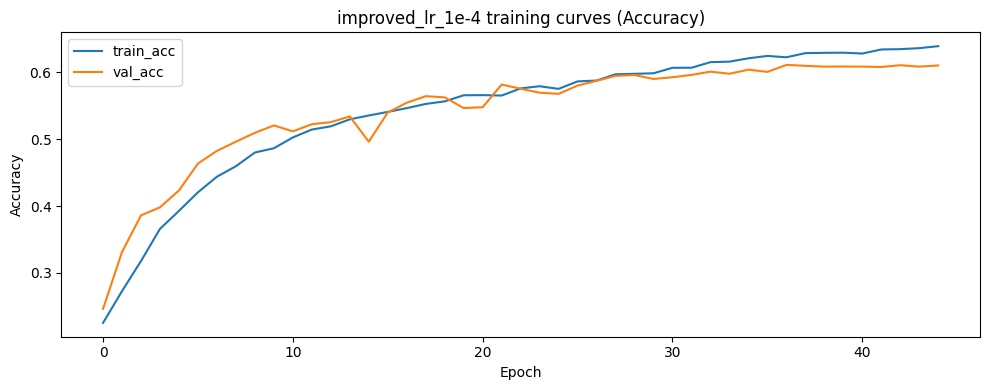

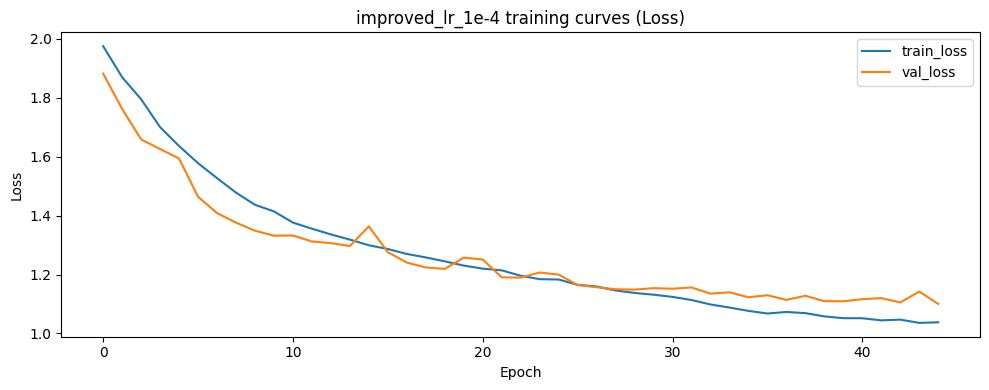

Best epoch by val_loss: 45


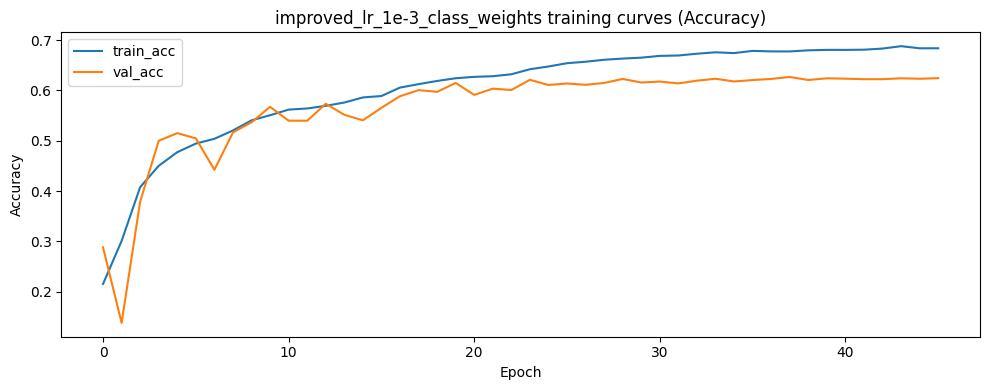

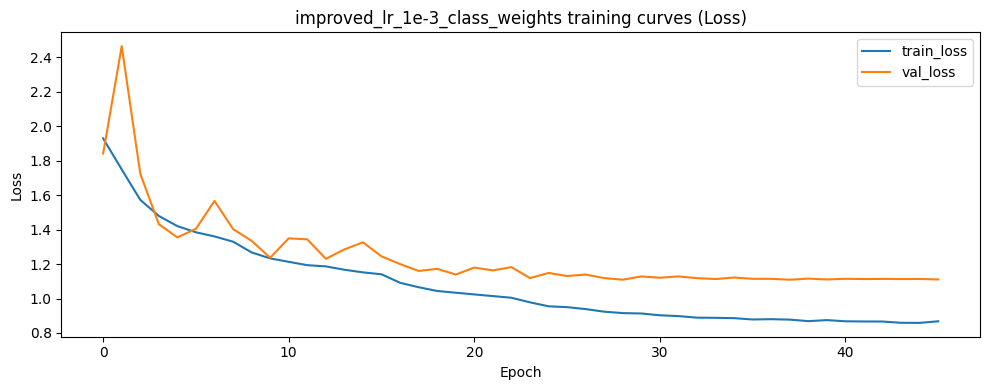

Best epoch by val_loss: 38


In [24]:
for name, history in all_histories.items():
    plot_history(history, title=f"{name} training curves")

## Final retraining

After the best experiment is identified, the chosen architecture is rebuilt and retrained on the combined training and validation data for the selected number of epochs. This is an important final step because it allows the model to learn from all available development data while still respecting the stopping point identified during validation.

The test set remains untouched until this stage, so the final test evaluation remains an unbiased measure of generalisation.

In [25]:
full_train_raw = train_dataset_raw.concatenate(val_dataset_raw)
full_train = configure_ds(full_train_raw, training=True)

best_exp = next(e for e in experiments if e["name"] == best_name)

# If the selected model used class weights, recompute them on train+validation.
# This avoids using weights estimated from only the original training subset.
final_class_weight = best_exp["class_weight"]
if final_class_weight is not None:
    full_train_labels = labels_from_dataset(full_train_raw)
    final_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=full_train_labels,
    )
    final_class_weight = {
        int(i): float(min(w, MAX_CLASS_WEIGHT))
        for i, w in enumerate(final_weights)
    }

tf.keras.backend.clear_session()
final_model = best_exp["build_fn"](**best_exp["build_kwargs"])

final_history = final_model.fit(
    full_train,
    epochs=best_epoch,
    class_weight=final_class_weight,
    verbose=1,
)

final_test_loss, final_test_acc = final_model.evaluate(test_dataset, verbose=0)
print(f"Final held-out test accuracy: {final_test_acc:.4f}")


Epoch 1/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 195s 399ms/step - accuracy: 0.2846 - loss: 1.8684
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 185s 396ms/step - accuracy: 0.4337 - loss: 1.5451
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 201s 432ms/step - accuracy: 0.4827 - loss: 1.4272
Epoch 4/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 193s 412ms/step - accuracy: 0.5162 - loss: 1.3606
Epoch 5/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 191s 409ms/step - accuracy: 0.5349 - loss: 1.3208
Epoch 6/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 194s 415ms/step - accuracy: 0.5497 - loss: 1.2875
Epoch 7/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 192s 412ms/step - accuracy: 0.5618 - loss: 1.2703
Epoch 8/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 191s 409ms/step - accuracy: 0.5661 - loss: 1.2470
Epoch 9/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 193s 415ms/step - accuracy: 0.5758 - loss: 1.2333
Epoch 10/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 221s 451ms/step - accuracy: 0.5859 - loss: 1.2213
Epoch 11/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 200s 424ms/step - accuracy: 0.5902 - loss: 1.2101
Epoch 12

In [26]:
final_summary = pd.DataFrame([
    {
        "selected_model": best_name,
        "selection_metric": "validation accuracy",
        "selected_epoch": best_epoch,
        "final_test_loss": final_test_loss,
        "final_test_accuracy": final_test_acc,
    }
])

final_summary


,selected_model,selection_metric,selected_epoch,final_test_loss,final_test_accuracy
0,improved_lr_1e-3,validation accuracy,40,1.208562,0.632627


## Final evaluation

The final evaluation section reports the confusion matrix, predicted class counts, and classification report for the selected best model on the test set. These outputs are important because they reveal class specific strengths and weaknesses that are not visible from overall accuracy alone.

In the current run, the final accuracy reported in the classification table is approximately 0.632, which is consistent with the accuracy reported for the best model in the results table.

In [27]:
def collect_predictions(model, dataset):
    y_true, y_pred = [], []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)
        y_true.append(y_batch.numpy())
        y_pred.append(np.argmax(probs, axis=1))

    return np.concatenate(y_true), np.concatenate(y_pred)

# Official final predictions: use the retrained final model on the held-out test set.
y_true, y_pred = collect_predictions(final_model, test_dataset)


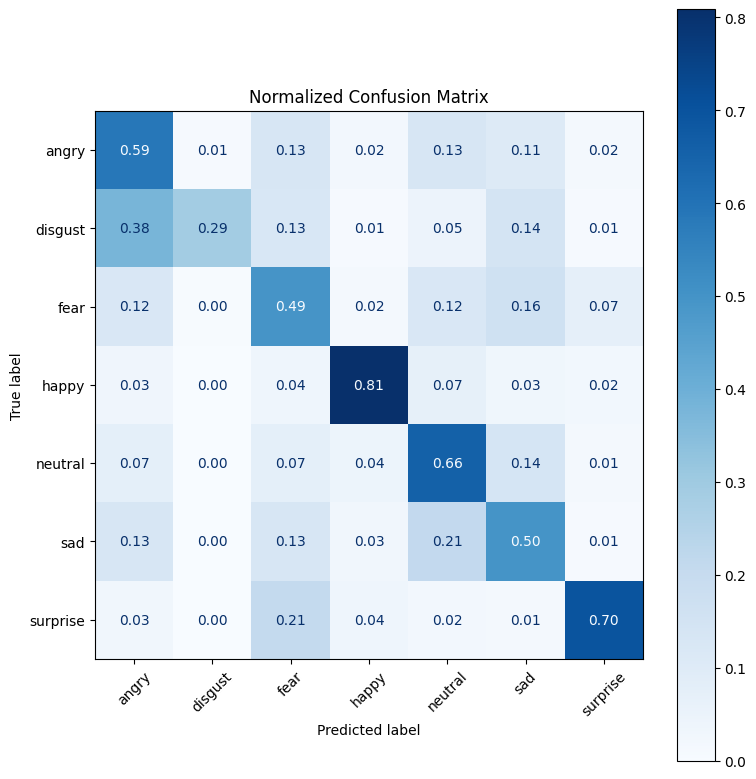

In [28]:
cm = confusion_matrix(y_true, y_pred, normalize="true")  # normalize by true class counts

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", values_format=".2f")  # show proportions

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

## Confusion matrix interpretation

The confusion matrix shows that the model is strongest on classes such as `happy` and `surprise`, which have clearer visual signals and are easier to distinguish. The classification report supports this, with F1 scores of about 0.852 for `happy` and 0.736 for `surprise`. Performance is weaker on classes such as `fear` and `disgust`, where the model achieves lower recall and F1 score. In particular, `disgust` has recall around 0.288 and `fear` has recall around 0.494 in the final report.

This pattern is consistent with the nature of the task. Some emotions are more visually distinctive than others, and minority classes are also harder to model reliably.

In [29]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=3,
    output_dict=True  # return as dict for structured analysis
)

report_df = pd.DataFrame(report).transpose()  # convert to DataFrame for readability
report_df.round(3)

,precision,recall,f1-score,support
angry,0.528,0.586,0.555,958.000
disgust,0.667,0.288,0.403,111.000
fear,0.447,0.494,0.469,1024.000
happy,0.901,0.809,0.852,1774.000
neutral,0.553,0.656,0.600,1233.000
sad,0.543,0.497,0.519,1247.000
surprise,0.781,0.696,0.736,831.000
accuracy,0.633,0.633,0.633,0.633
macro avg,0.632,0.575,0.591,7178.000
weighted avg,0.647,0.633,0.637,7178.000


## Transfer learning experiment

The notebook also includes a transfer learning comparison using MobileNetV2. This experiment investigates whether pretrained visual features can improve performance on the FER task. The transfer model is first trained with a frozen convolutional backbone and then briefly fine tuned with a small number of upper layers unfrozen.

In the current run, transfer learning does not outperform the best scratch CNN. The frozen MobileNetV2 model reaches validation accuracy 0.5187, while the fine tuned version reaches validation accuracy of 0.5068. Both are substantially below the best improved scratch model.

This is still a valid and useful result. It shows that transfer learning was tested systematically, but that in this case the custom CNN architecture is better suited to the dataset.

Epoch 1/15
   1435/Unknown 110s 48ms/step - accuracy: 0.2911 - loss: 2.0795

C:\Users\palim\Documents\miniconda\envs\DM\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from None to 0.43930, saving model to runs\mobilenetv2_frozen\best.weights.h5
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 129s 61ms/step - accuracy: 0.3490 - loss: 1.8348 - val_accuracy: 0.4393 - val_loss: 1.5015 - learning_rate: 1.0000e-04
Epoch 2/15

Epoch 2: val_accuracy improved from 0.43930 to 0.47135, saving model to runs\mobilenetv2_frozen\best.weights.h5
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 119s 62ms/step - accuracy: 0.4306 - loss: 1.5122 - val_accuracy: 0.4713 - val_loss: 1.4193 - learning_rate: 1.0000e-04
Epoch 3/15

Epoch 3: val_accuracy improved from 0.47135 to 0.48633, saving model to runs\mobilenetv2_frozen\best.weights.h5
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 121s 61ms/step - accuracy: 0.4734 - loss: 1.4054 - val_accuracy: 0.4863 - val_loss: 1.3798 - learning_rate: 1.0000e-04
Epoch 4/15

Epoch 4: val_accuracy improved from 0.48633 to 0.49608, saving model to runs\mobilenetv2_frozen\best.weights.h5
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 113s 57ms/step - accuracy: 0.4978 - l

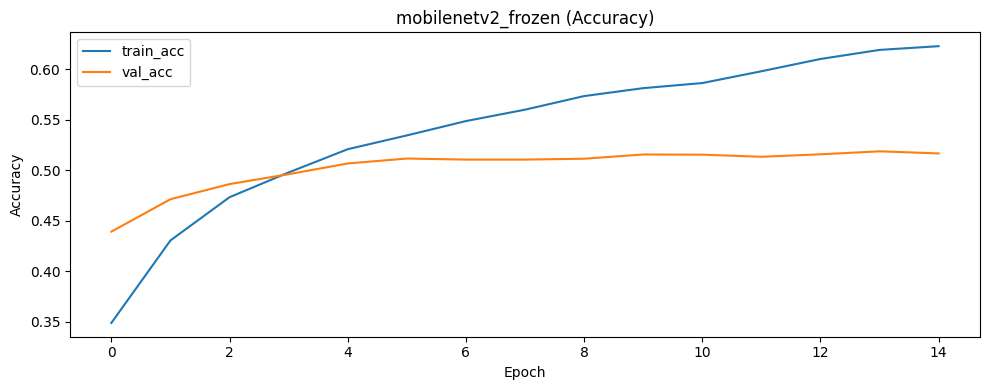

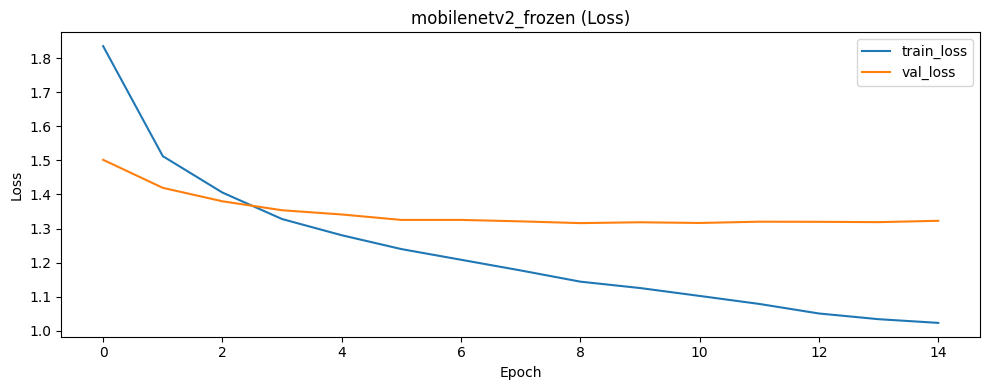

Best epoch by val_loss: 9
Epoch 1/8

Epoch 1: val_accuracy improved from None to 0.44853, saving model to runs\mobilenetv2_finetuned\best.weights.h5
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 158s 72ms/step - accuracy: 0.4110 - loss: 1.6240 - val_accuracy: 0.4485 - val_loss: 1.5705 - learning_rate: 5.0000e-06
Epoch 2/8

Epoch 2: val_accuracy improved from 0.44853 to 0.47291, saving model to runs\mobilenetv2_finetuned\best.weights.h5
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 144s 73ms/step - accuracy: 0.4475 - loss: 1.5019 - val_accuracy: 0.4729 - val_loss: 1.4599 - learning_rate: 5.0000e-06
Epoch 3/8

Epoch 3: val_accuracy improved from 0.47291 to 0.47744, saving model to runs\mobilenetv2_finetuned\best.weights.h5
1436/1436 ━━━━━━━━━━━━━━━━━━━━ 140s 72ms/step - accuracy: 0.4714 - loss: 1.4360 - val_accuracy: 0.4774 - val_loss: 1.4362 - learning_rate: 5.0000e-06
Epoch 4/8

Epoch 4: val_accuracy improved from 0.47744 to 0.48337, saving model to runs\mobilenetv2_finetuned\best.weights.h5
1436/1436 ━━━━━━━━━━━━━

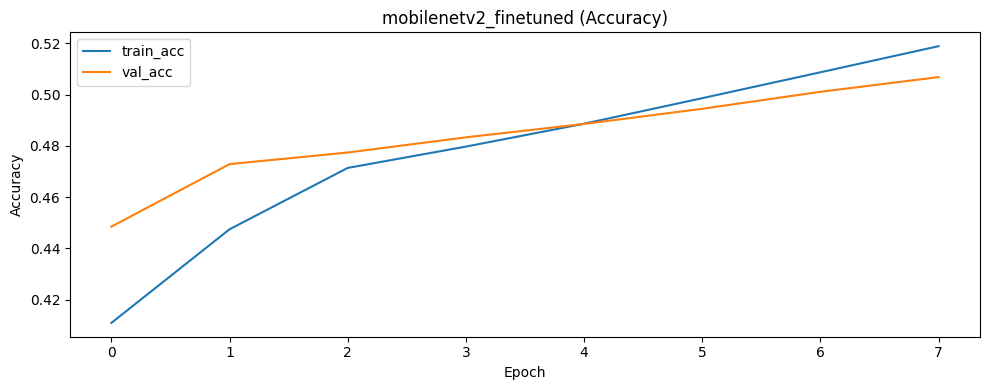

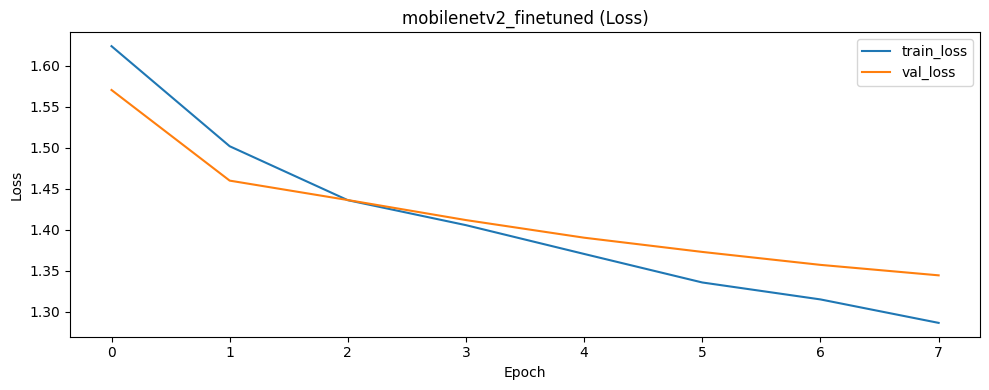

Best epoch by val_loss: 8


,name,val_loss,val_accuracy,best_epoch,epochs_ran,class_weight,lr,dropout_rate,use_augmentation,dropout_head,weight_decay,use_adamw,model_family,lr_head,lr_finetune,unfrozen_layers
0,improved_lr_1e-3,1.096856,0.640829,40,48,False,0.0010,NaN,True,0.4,0.0001,True,NaN,NaN,NaN,NaN
1,improved_deeper_adamw_aug,1.064922,0.638216,55,63,False,0.0003,NaN,True,0.4,0.0001,True,NaN,NaN,NaN,NaN
2,improved_lr_1e-3_class_weights,1.109018,0.626546,38,46,True,0.0010,NaN,True,0.4,0.0001,True,NaN,NaN,NaN,NaN
3,improved_deeper_adamw,1.297342,0.624107,36,44,False,0.0003,NaN,False,0.4,0.0001,True,NaN,NaN,NaN,NaN
4,improved_lr_1e-4,1.113927,0.611218,37,45,False,0.0001,NaN,True,0.4,0.0001,True,NaN,NaN,NaN,NaN
5,baseline_cnn,1.212202,0.554607,32,40,False,0.0010,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,mobilenetv2_frozen,1.318703,0.518725,14,15,False,NaN,NaN,NaN,NaN,NaN,NaN,transfer,0.0001,NaN,0.0
7,mobilenetv2_finetuned,1.344338,0.506880,8,8,False,NaN,NaN,NaN,NaN,NaN,NaN,transfer,0.0001,0.000005,20.0


In [30]:
tf.keras.backend.clear_session()

# Frozen-head training. This is treated as another validation-only experiment.
transfer_model, transfer_base = build_transfer_model(
    dense_units=128,
    dropout_rate=0.3,
    lr_head=1e-4,
)

transfer_history = transfer_model.fit(
    train_dataset_tl,
    epochs=15,
    validation_data=val_dataset_tl,
    callbacks=make_callbacks("mobilenetv2_frozen"),
    class_weight=None,
    verbose=1,
)

transfer_best_epoch = int(np.argmax(transfer_history.history["val_accuracy"]) + 1)
transfer_val_loss, transfer_val_acc = transfer_model.evaluate(val_dataset_tl, verbose=0)

frozen_result = {
    "name": "mobilenetv2_frozen",
    "val_loss": float(transfer_val_loss),
    "val_accuracy": float(transfer_val_acc),
    "best_epoch": transfer_best_epoch,
    "epochs_ran": len(transfer_history.history["loss"]),
    "model_family": "transfer",
    "lr_head": 1e-4,
    "lr_finetune": None,
    "unfrozen_layers": 0,
    "class_weight": False,
}
all_models[frozen_result["name"]] = transfer_model
all_histories[frozen_result["name"]] = transfer_history
all_results.append(frozen_result)

print(f"mobilenetv2_frozen val_acc: {transfer_val_acc:.4f}")
plot_history(transfer_history, title="mobilenetv2_frozen")

# Fine-tuning: unfreeze only the last few layers and use a very small learning rate.
transfer_base.trainable = True
UNFREEZE_LAST = 20

for layer in transfer_base.layers[:-UNFREEZE_LAST]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = transfer_model.fit(
    train_dataset_tl,
    epochs=8,
    validation_data=val_dataset_tl,
    callbacks=make_callbacks("mobilenetv2_finetuned"),
    class_weight=None,
    verbose=1,
)

ft_best_epoch = int(np.argmax(fine_tune_history.history["val_accuracy"]) + 1)
ft_val_loss, ft_val_acc = transfer_model.evaluate(val_dataset_tl, verbose=0)

finetuned_result = {
    "name": "mobilenetv2_finetuned",
    "val_loss": float(ft_val_loss),
    "val_accuracy": float(ft_val_acc),
    "best_epoch": ft_best_epoch,
    "epochs_ran": len(fine_tune_history.history["loss"]),
    "model_family": "transfer",
    "lr_head": 1e-4,
    "lr_finetune": 5e-6,
    "unfrozen_layers": UNFREEZE_LAST,
    "class_weight": False,
}
all_models[finetuned_result["name"]] = transfer_model
all_histories[finetuned_result["name"]] = fine_tune_history
all_results.append(finetuned_result)

print(f"mobilenetv2_finetuned val_acc: {ft_val_acc:.4f}")
plot_history(fine_tune_history, title="mobilenetv2_finetuned")

results_df = (
    pd.DataFrame(all_results)
    .sort_values("val_accuracy", ascending=False)
    .reset_index(drop=True)
)

results_df


## Predicted class distribution

The predicted class counts show that the current best model does predict every class, including `disgust`. There was an earlier issue of zero predicted `disgust` cases, but that is no longer present in this run. In the current export, the model predicts `disgust` 48 times, compared with 1593 predictions for `happy` and 1462 for `neutral`.

This is still an imbalanced prediction pattern, but it is much healthier than a complete class collapse. It suggests that the model has at least learned a usable decision boundary for the minority class, even though recall remains relatively weak.

In [31]:
pred_counts = pd.Series(y_pred).value_counts().sort_index()
pred_counts.index = [CLASS_NAMES[i] for i in pred_counts.index]

print("Predicted class counts from the final retrained model:")
print(pred_counts)

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=3,
    output_dict=True,
)

report_df = pd.DataFrame(report).transpose()
report_df.round(3)


Predicted class counts from the final retrained model:
angry       1062
disgust       48
fear        1132
happy       1593
neutral     1462
sad         1141
surprise     740
Name: count, dtype: int64


,precision,recall,f1-score,support
angry,0.528,0.586,0.555,958.000
disgust,0.667,0.288,0.403,111.000
fear,0.447,0.494,0.469,1024.000
happy,0.901,0.809,0.852,1774.000
neutral,0.553,0.656,0.600,1233.000
sad,0.543,0.497,0.519,1247.000
surprise,0.781,0.696,0.736,831.000
accuracy,0.633,0.633,0.633,0.633
macro avg,0.632,0.575,0.591,7178.000
weighted avg,0.647,0.633,0.637,7178.000


## Classification report interpretation

The classification report gives a more detailed view of the final model’s behaviour. Overall accuracy is about 0.633. The strongest class is `happy`, with precision around 0.901, recall around 0.809, and F1 score around 0.852. `Surprise` is also strong, with F1 around 0.736. At the other end, `disgust` has F1 around 0.403 and `fear` has F1 around 0.469. `Neutral` and `sad` lie in the middle, with F1 scores around 0.600 and 0.519 respectively.

This pattern suggests that the model is effective overall but still struggles with subtle or underrepresented expressions. That is a realistic outcome for this dataset and helps motivate the inclusion of class weighting and error analysis in the notebook.

## Misclassified examples

The misclassified examples provide a concrete view of the model’s errors. In emotion recognition, many errors arise from overlap between visually similar categories such as fear and surprise or neutral and sad. Low resolution images can make this problem worse because subtle expression details are lost.

This section therefore complements the confusion matrix by showing the types of inputs that remain difficult even for the best model.

Misclassified: 2637 of 7178


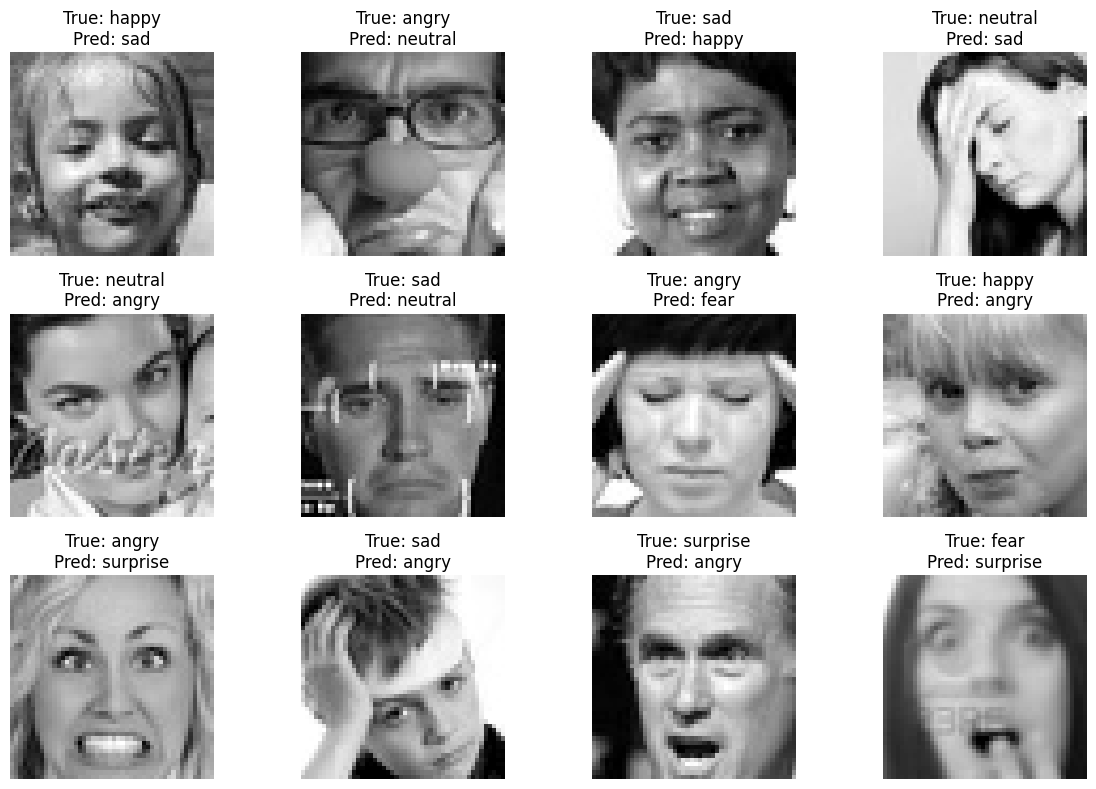

In [32]:
mis_idx = np.where(y_true != y_pred)[0]  # indices of incorrect predictions
print("Misclassified:", len(mis_idx), "of", len(y_true))

test_images = np.concatenate([x.numpy() for x, _ in test_dataset_raw], axis=0)  # original grayscale images for display

rng = np.random.default_rng(SEED)  # reproducible random sample of mistakes
sample = rng.choice(mis_idx, size=min(12, len(mis_idx)), replace=False)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample):
    plt.subplot(3, 4, i + 1)
    img = test_images[idx].squeeze()  # remove channel dimension
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Grad CAM visualisation

Grad CAM is used as an interpretability tool to visualise which regions of the face influence a prediction most strongly. The highlighted regions correspond mainly to the eyes, mouth, eyebrows, and central facial structure, which supports the interpretation that the model is learning relevant emotional cues rather than arbitrary artefacts.

This section adds depth to the report because it moves beyond raw performance and considers how the model arrives at its decisions.

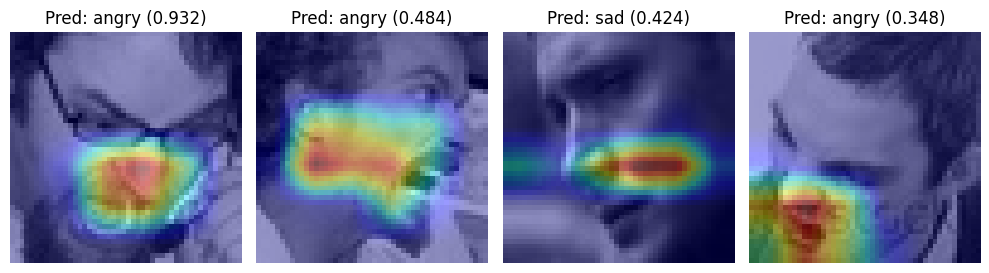

In [33]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")


def build_gradcam_model(model):
    last_conv_name = find_last_conv_layer(model)
    last_conv_layer = model.get_layer(last_conv_name)
    return keras.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output],
    )


def make_gradcam_heatmap(img_array, gradcam_model, pred_index=None):
    img_array = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_out, preds = gradcam_model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy(), preds[0].numpy()


def display_gradcam(image_48x48, model, alpha=0.4):
    img_array = tf.expand_dims(image_48x48, axis=0)

    gradcam_model = build_gradcam_model(model)
    heatmap, preds = make_gradcam_heatmap(img_array, gradcam_model)
    pred_index = int(np.argmax(preds))

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE,
    ).numpy().squeeze()

    img_np = image_48x48.numpy().squeeze()
    plt.imshow(img_np, cmap="gray")
    plt.imshow(heatmap_resized, cmap="jet", alpha=alpha)
    plt.title(f"Pred: {CLASS_NAMES[pred_index]} ({preds[pred_index]:.3f})")
    plt.axis("off")


# Grad-CAM is shown for the final retrained CNN model.
for images, labels in test_dataset_raw.take(1):
    plt.figure(figsize=(10, 5))
    num_images = min(4, images.shape[0])
    for i in range(num_images):
        plt.subplot(1, 4, i + 1)
        display_gradcam(images[i], final_model)
    plt.tight_layout()
    plt.show()


## Saving artefacts

The final section saves the experiment results table, the trained final model, and any auxiliary files needed to interpret predictions. This ensures that the outputs of the notebook are organised and reproducible.

In [34]:
results_df.to_csv(OUTPUT_DIR / "validation_experiment_results.csv", index=False)
final_summary.to_csv(OUTPUT_DIR / "final_test_summary.csv", index=False)
final_model.save(OUTPUT_DIR / "final_emotion_model.keras")

print("Saved validation results to:", OUTPUT_DIR / "validation_experiment_results.csv")
print("Saved final test summary to:", OUTPUT_DIR / "final_test_summary.csv")
print("Saved final model to:", OUTPUT_DIR / "final_emotion_model.keras")


Saved validation results to: outputs\validation_experiment_results.csv
Saved final test summary to: outputs\final_test_summary.csv
Saved final model to: outputs\final_emotion_model.keras


## Conclusion

This notebook demonstrates a complete image-classification workflow: a non-neural baseline, a small CNN that beats that baseline, systematic CNN experiments, validation-based model selection, final retraining, and held-out test evaluation. The error analysis uses a confusion matrix, classification report, misclassified examples, and Grad-CAM to move beyond a single accuracy score and inspect where the model succeeds or fails.

The strongest portfolio point is the controlled experiment runner, which makes it easy to compare architecture and optimisation choices consistently. The main limitation is that FER-style facial emotion recognition remains intrinsically noisy: some labels overlap visually, and classes such as fear/disgust are harder to separate than happy/surprise.


## References

Goodfellow et al. (2013), FER2013 dataset:
https://www.kaggle.com/datasets/msambare/fer2013

This project makes use of TensorFlow and Keras APIs for model building, data loading, and training.

TensorFlow Keras documentation for MobileNetV2:
https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2

TensorFlow dataset loading utilities:
https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory

Grad-CAM method adapted from:
Selvaraju et al. (2017), Grad-CAM: Visual Explanations from Deep Networks
https://openaccess.thecvf.com/content_ICCV_2017/papers/Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.pdf

Parts of the CNN architectures, training workflow, and data pipeline were adapted from lecture materials and the book *Deep Learning with Python* by François Chollet.